# **Ensemble Methods (Adaboost)**

Dataset: Environment_Temperature_change_E_All_Data_NOFLAG.csv
- The dataset explores the mean surface temperature change by country, with annual updates.

AdaBoost is an ensemble learning algorithm that builds a strong classifier by combining multiple "weak learners," typically simple decision stumps. Unlike other methods, it operates sequentially, assigning higher weights to data points that were misclassified in previous rounds. This forces each new model to focus on the most difficult cases, effectively "learning from its mistakes" to improve accuracy. In the context of this dataset, it synthesizes 4,811 regional temperature features into a robust global predictor by emphasizing the specific geographic markers that are hardest to classify.




In [ ]:
## load in packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
## load in dataset and clean data
df = pd.read_csv("Environment_Temperature_change_E_All_Data_NOFLAG.csv", encoding='latin1')
df = df[df['Element'] == 'Temperature change']
year_cols = [col for col in df.columns if col.startswith('Y')]
data = df[year_cols].transpose()
data.columns = df['Area']
data = data.fillna(data.mean())

In [ ]:
# define target
target_country = 'World'

# Grab the 'World' column. If your data has a MultiIndex (tuples),
# Grab the first one to use as our labels.
world_data = data[target_country]
if isinstance(world_data, pd.DataFrame):
    world_series = world_data.iloc[:, 0]
else:
    world_series = world_data

median_val = world_series.median()
y = (world_series > median_val).astype(int)

# remove all world columns
# this list comprehension ensures no 'World' data remains in X.
X = data.drop(columns=[col for col in data.columns if target_country in str(col)])

# --- TEST THE FIX ---
print(f"Is 'World' in X? {'World' in X.columns}") # Should be False
print(f"Number of features in X: {X.shape[1]}")

Is 'World' in X? False
Number of features in X: 4811


In [ ]:
# split the target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# initialize adaboost
ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    learning_rate=0.5,
    random_state=42
)

In [ ]:
# train & predict
ada_clf.fit(X_train, y_train)
y_pred = ada_clf.predict(X_test)

In [ ]:
# adaboost result
print(f"AdaBoost Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

AdaBoost Accuracy: 0.83

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.83      0.83         6
           1       0.83      0.83      0.83         6

    accuracy                           0.83        12
   macro avg       0.83      0.83      0.83        12
weighted avg       0.83      0.83      0.83        12



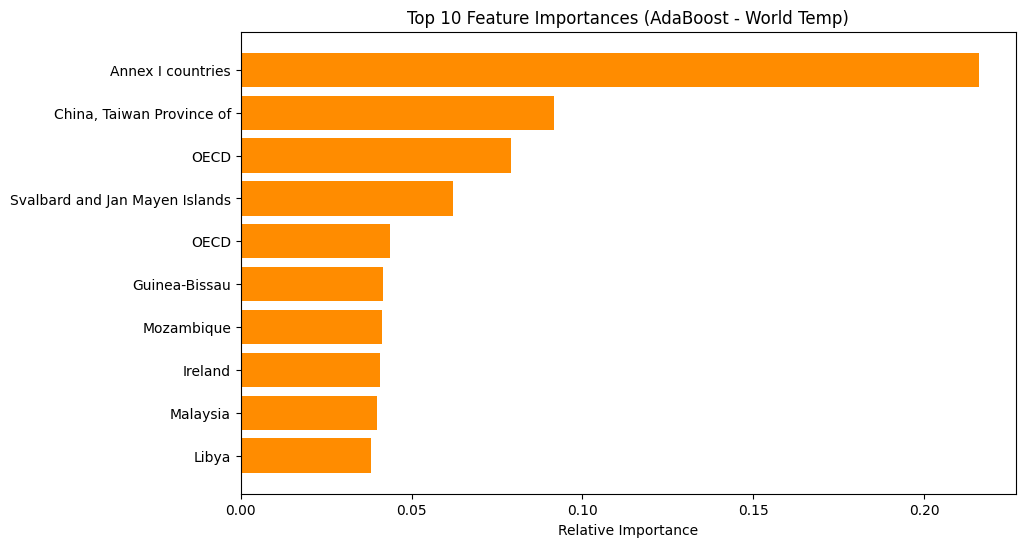

In [ ]:
# graphing adaboost
# 7. Graph: Feature Importance for AdaBoost
importances = ada_clf.feature_importances_
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10, 6))
plt.title("Top 10 Feature Importances (AdaBoost - World Temp)")
plt.barh(range(len(indices)), importances[indices], color='darkorange', align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

The top bar shows Annex I countries as the dominant predictor, followed closely by OECD nations. The model discovered that temperature fluctuations in industrialized nations are the most reliable "mirrors" for global temperature change. If you know what's happening in the OECD, you have a very high-probability guess for what's happening to the World average.